# 🎓 Smart Campus Recruitment System
## Model 1 — Resume Parser (NER + BERT Fine-tuning)

**Dataset:** [Resume Entities for NER](https://www.kaggle.com/datasets/dataturks/resume-entities-for-ner)  
**Supplementary:** [Updated Resume Dataset](https://www.kaggle.com/datasets/jillanisofttech/updated-resume-dataset)

**Pipeline:**
1. Dataset loading & exploration (EDA)
2. Preprocessing & BIO tagging
3. Visualizations
4. Feature engineering & normalization
5. PCA analysis
6. Train / Val / Test split
7. BERT fine-tuning for token classification (NER)
8. Evaluation & inference
9. JSON output for downstream models

**Entities extracted:** Name, Email, Phone, Skills, Education/Degree, College, Company, Designation, Location, Years of Experience, Graduation Year, Certification


## 📦 Cell 1 — Install & import dependencies

In [ ]:
# ── Install (run once on Kaggle) ──────────────────────────────────────────────
import subprocess, sys
def pip(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

pip('transformers[torch]')
pip('datasets')
pip('seqeval')          # NER evaluation metric
pip('spacy')
pip('wordcloud')
pip('umap-learn')

# ── Standard imports ─────────────────────────────────────────────────────────
import os, re, json, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter, defaultdict
from wordcloud import WordCloud
warnings.filterwarnings('ignore')

# ── ML / DL ──────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import umap

# ── HuggingFace ───────────────────────────────────────────────────────────────
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification,
    TrainingArguments, Trainer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback
)

# ── Seeds for reproducibility ─────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Plotting style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
PALETTE = sns.color_palette('tab20', 20)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.10.0+cu128


## 📂 Cell 2 — Load the dataset

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PRIMARY DATASET: Resume Entities for NER (Dataturks)
# Colab path: /content/Entity Recognition in Resumes.json
#
# SUPPLEMENTARY: Updated Resume Dataset (category labels)
# Colab path: /content/UpdatedResumeDataSet.csv
# ─────────────────────────────────────────────────────────────────────────────

NER_PATH = '/content/Entity Recognition in Resumes.json'
CAT_PATH = '/content/UpdatedResumeDataSet.csv'

# ── Load NER dataset (JSONL — one JSON object per line) ───────────────────────
raw_records = []
with open(NER_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            raw_records.append(json.loads(line))

print(f'Total NER records loaded : {len(raw_records)}')
print('\nSample record keys:', list(raw_records[0].keys()))
print('\n── Sample annotation ──')
sample = raw_records[0]
print('Content snippet:', sample['content'][:200])
if 'annotation' in sample and sample['annotation']:
    print('\nFirst 3 annotations:')
    for ann in sample['annotation'][:3]:
        print(' ', ann)

# ── Load category dataset ─────────────────────────────────────────────────────
df_cat = pd.read_csv(CAT_PATH)
print(f'\nCategory dataset shape: {df_cat.shape}')
print(df_cat.head(3))

Total NER records loaded : 220

Sample record keys: ['content', 'annotation', 'extras']

── Sample annotation ──
Content snippet: Abhishek Jha
Application Development Associate - Accenture

Bengaluru, Karnataka - Email me on Indeed: indeed.com/r/Abhishek-Jha/10e7a8cb732bc43a

• To work for an organization which provides me the o

First 3 annotations:
  {'label': ['Skills'], 'points': [{'start': 1295, 'end': 1621, 'text': '\n• Programming language: C, C++, Java\n• Oracle PeopleSoft\n• Internet Of Things\n• Machine Learning\n• Database Management System\n• Computer Networks\n• Operating System worked on: Linux, Windows, Mac\n\nNon - Technical Skills\n\n• Honest and Hard-Working\n• Tolerant and Flexible to Different Situations\n• Polite and Calm\n• Team-Player'}]}
  {'label': ['Skills'], 'points': [{'start': 993, 'end': 1153, 'text': 'C (Less than 1 year), Database (Less than 1 year), Database Management (Less than 1 year),\nDatabase Management System (Less than 1 year), Java (Less than 1

## 🔬 Cell 3 — Parse & flatten the NER annotations

In [ ]:
# ── Entity label mapping (normalise inconsistent label names) ─────────────────
LABEL_NORM = {
    'Name'             : 'NAME',
    'Email Address'    : 'EMAIL',
    'Phone Number'     : 'PHONE',
    'Skills'           : 'SKILLS',
    'Degree'           : 'DEGREE',
    'College Name'     : 'COLLEGE',
    'Companies worked at': 'COMPANY',
    'Designation'      : 'DESIGNATION',
    'Location'         : 'LOCATION',
    'Years of Experience': 'EXPERIENCE',
    'Graduation Year'  : 'GRAD_YEAR',
    'Certification'    : 'CERTIFICATION',
    'Links'            : 'LINKS',
}

# ── Flatten to a DataFrame of spans ───────────────────────────────────────────
records_flat = []
for idx, rec in enumerate(raw_records):
    text = rec.get('content', '')
    annotations = rec.get('annotation') or []
    entities = []
    for ann in annotations:
        label_raw = ann.get('label', [''])
        if isinstance(label_raw, list):
            label_raw = label_raw[0] if label_raw else ''
        label = LABEL_NORM.get(label_raw, label_raw.upper().replace(' ', '_'))
        points = ann.get('points', [])
        for pt in points:
            start = pt.get('start', 0)
            end   = pt.get('end', 0)
            value = pt.get('text', text[start:end+1]).strip()
            entities.append({'label': label, 'start': start, 'end': end+1,
                             'value': value})
            records_flat.append({
                'resume_id': idx,
                'text_len' : len(text),
                'label'    : label,
                'value'    : value,
                'span_len' : end + 1 - start
            })

df_spans = pd.DataFrame(records_flat)
print(f'Total entity spans : {len(df_spans)}')
print(f'Unique labels      : {df_spans["label"].nunique()}')
print(f'Unique resumes     : {df_spans["resume_id"].nunique()}')
print('\nEntity distribution:')
print(df_spans['label'].value_counts())

Total entity spans : 3558
Unique labels      : 12
Unique resumes     : 220

Entity distribution:
label
COMPANY        729
DESIGNATION    521
SKILLS         472
LOCATION       430
COLLEGE        330
DEGREE         298
GRAD_YEAR      254
EMAIL          252
NAME           224
EXPERIENCE      44
UNKNOWN          2
                 2
Name: count, dtype: int64


## 📊 Cell 4 — Exploratory Data Analysis (EDA)

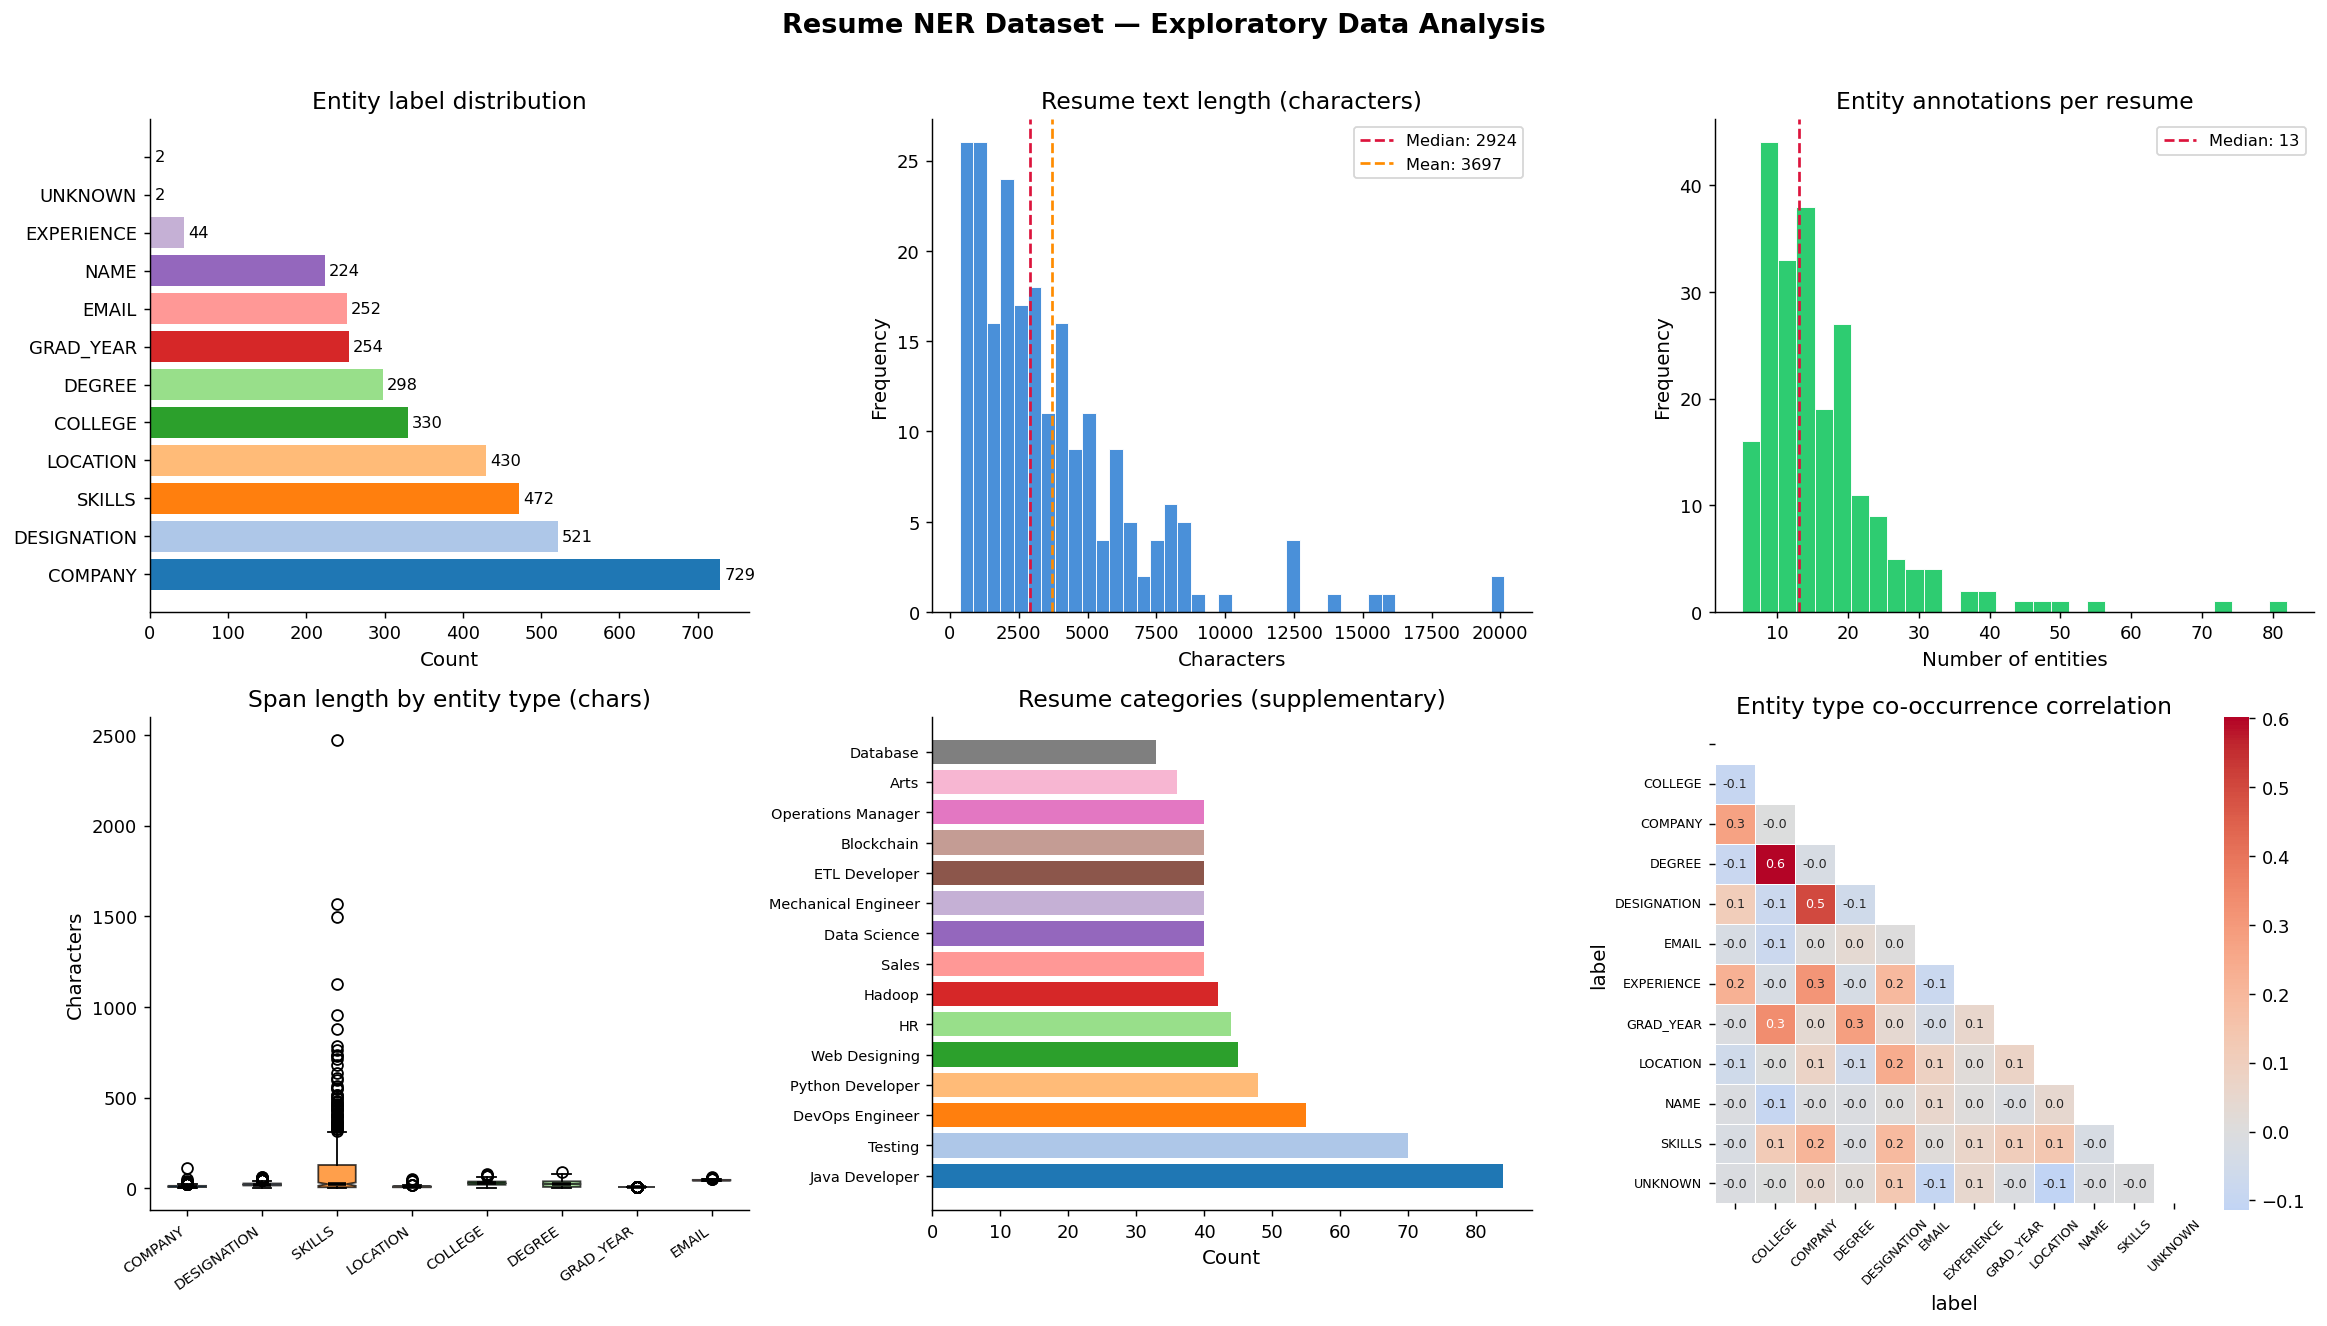

EDA overview saved.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Resume NER Dataset — Exploratory Data Analysis', fontsize=15, fontweight='bold', y=1.01)

# ── 1. Entity label distribution ──────────────────────────────────────────────
ax = axes[0, 0]
vc = df_spans['label'].value_counts()
bars = ax.barh(vc.index, vc.values, color=PALETTE[:len(vc)])
ax.set_title('Entity label distribution')
ax.set_xlabel('Count')
for bar, v in zip(bars, vc.values):
    ax.text(v + 5, bar.get_y() + bar.get_height()/2, str(v),
            va='center', fontsize=9)

# ── 2. Resume text length distribution ───────────────────────────────────────
ax = axes[0, 1]
text_lens = [len(r['content']) for r in raw_records]
ax.hist(text_lens, bins=40, color='#4A90D9', edgecolor='white', linewidth=0.5)
ax.axvline(np.median(text_lens), color='crimson', linestyle='--', label=f'Median: {int(np.median(text_lens))}')
ax.axvline(np.mean(text_lens), color='darkorange', linestyle='--', label=f'Mean: {int(np.mean(text_lens))}')
ax.set_title('Resume text length (characters)')
ax.set_xlabel('Characters'); ax.set_ylabel('Frequency')
ax.legend(fontsize=9)

# ── 3. Entities per resume ────────────────────────────────────────────────────
ax = axes[0, 2]
ent_per_resume = df_spans.groupby('resume_id').size()
ax.hist(ent_per_resume, bins=30, color='#2ECC71', edgecolor='white', linewidth=0.5)
ax.axvline(ent_per_resume.median(), color='crimson', linestyle='--',
           label=f'Median: {ent_per_resume.median():.0f}')
ax.set_title('Entity annotations per resume')
ax.set_xlabel('Number of entities'); ax.set_ylabel('Frequency')
ax.legend(fontsize=9)

# ── 4. Span length per entity type ───────────────────────────────────────────
ax = axes[1, 0]
top_labels = df_spans['label'].value_counts().head(8).index
data_box = [df_spans[df_spans['label'] == l]['span_len'].values for l in top_labels]
bp = ax.boxplot(data_box, patch_artist=True, notch=True,
                medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xticklabels(top_labels, rotation=35, ha='right', fontsize=8)
ax.set_title('Span length by entity type (chars)')
ax.set_ylabel('Characters')

# ── 5. Job category distribution (supplementary dataset) ─────────────────────
ax = axes[1, 1]
cat_vc = df_cat['Category'].value_counts().head(15)
ax.barh(cat_vc.index, cat_vc.values, color=PALETTE[:len(cat_vc)])
ax.set_title('Resume categories (supplementary)')
ax.set_xlabel('Count')
ax.tick_params(axis='y', labelsize=8)

# ── 6. Entity co-occurrence heatmap ──────────────────────────────────────────
ax = axes[1, 2]
pivot = df_spans.groupby(['resume_id', 'label']).size().unstack(fill_value=0)
corr = pivot.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.1f', annot_kws={'size': 7},
            linewidths=0.4, square=True)
ax.set_title('Entity type co-occurrence correlation')
ax.tick_params(axis='x', labelsize=7, rotation=45)
ax.tick_params(axis='y', labelsize=7, rotation=0)

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()
print('EDA overview saved.')

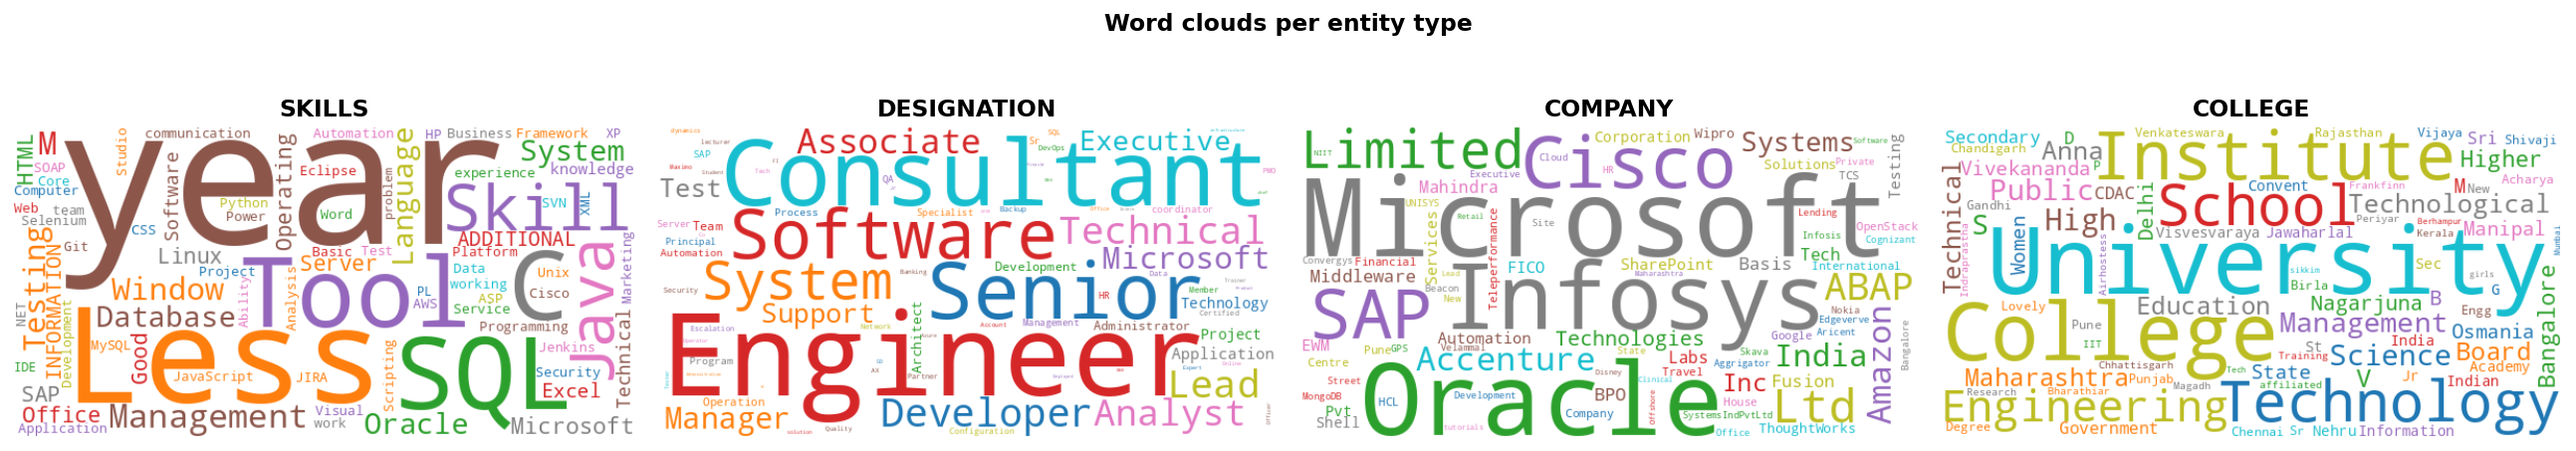

In [ ]:
# ── WordClouds per entity type ─────────────────────────────────────────────────
CLOUD_LABELS = ['SKILLS', 'DESIGNATION', 'COMPANY', 'COLLEGE']
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Word clouds per entity type', fontsize=13, fontweight='bold')

for ax, lbl in zip(axes, CLOUD_LABELS):
    subset = df_spans[df_spans['label'] == lbl]['value']
    text = ' '.join(subset.dropna().astype(str).values)
    wc = WordCloud(
        width=600, height=300, background_color='white',
        colormap='tab10', max_words=80, collocations=False
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(lbl, fontweight='bold')

plt.tight_layout()
plt.savefig('wordclouds_entities.png', bbox_inches='tight')
plt.show()

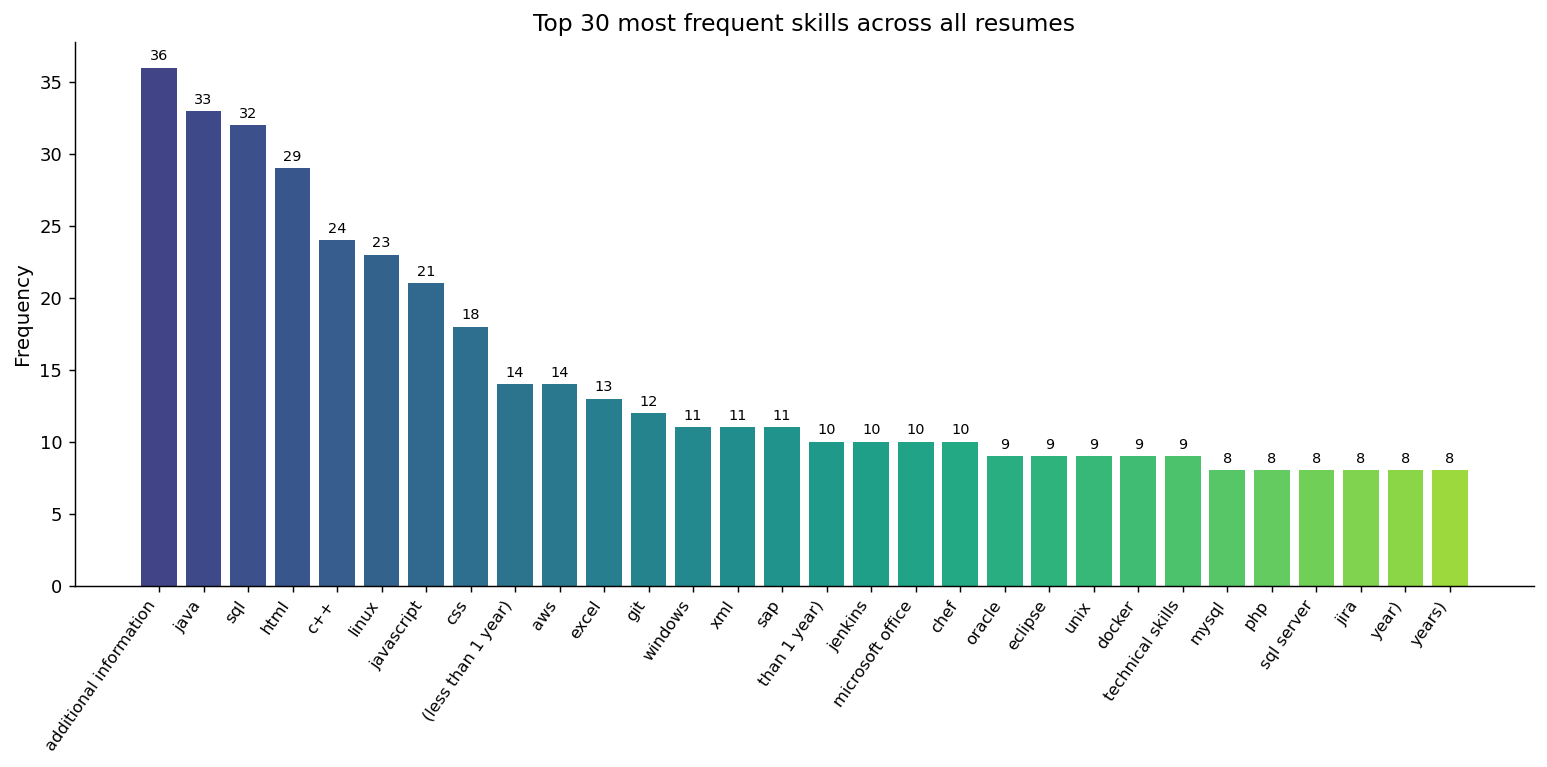

In [ ]:
# ── Top-30 most frequent skills ───────────────────────────────────────────────
skills_raw = df_spans[df_spans['label'] == 'SKILLS']['value'].dropna().astype(str)
all_skills = []
for s in skills_raw:
    for token in re.split(r'[,|\n/•·]', s):
        t = token.strip()
        if 2 < len(t) < 40:
            all_skills.append(t.lower())

skill_counts = Counter(all_skills).most_common(30)
sk_labels, sk_vals = zip(*skill_counts)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(sk_labels, sk_vals,
              color=plt.cm.viridis(np.linspace(0.2, 0.85, len(sk_labels))))
ax.set_title('Top 30 most frequent skills across all resumes', fontsize=13)
ax.set_ylabel('Frequency')
ax.set_xticklabels(sk_labels, rotation=55, ha='right', fontsize=9)
for bar, v in zip(bars, sk_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, str(v),
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('top_skills.png', bbox_inches='tight')
plt.show()

## ⚙️ Cell 5 — Preprocessing: BIO tag conversion

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Convert raw span annotations → word-level BIO (Beginning-Inside-Outside) tags
# BIO scheme:
#   B-SKILLS = first token of a SKILLS entity
#   I-SKILLS = continuation of a SKILLS entity
#   O        = not part of any entity
# ─────────────────────────────────────────────────────────────────────────────

def spans_to_bio(text, spans):
    """
    Given raw text and a list of (start, end, label) spans,
    return list of (word, BIO_tag) tuples.
    """
    # Build char-level label array
    char_labels = ['O'] * len(text)
    for start, end, label in spans:
        if start >= len(text): continue
        end = min(end, len(text))
        char_labels[start] = f'B-{label}'
        for i in range(start + 1, end):
            char_labels[i] = f'I-{label}'

    # Tokenize on whitespace, map to BIO using majority char label
    tokens, bio_tags = [], []
    pos = 0
    words = text.split()
    for word in words:
        # Find where this word starts in the original text
        start = text.find(word, pos)
        if start == -1:
            tokens.append(word); bio_tags.append('O')
            continue
        end = start + len(word)
        span_lbl = char_labels[start]  # use the start character's label
        tokens.append(word)
        bio_tags.append(span_lbl)
        pos = end

    return list(zip(tokens, bio_tags))


# ── Build sentence-level NER dataset ─────────────────────────────────────────
ner_sentences = []   # list of lists: each item = [(word, tag), ...]
label_set = set(['O'])

for rec in raw_records:
    text = rec.get('content', '')
    annotations = rec.get('annotation') or []

    spans = []
    for ann in annotations:
        label_raw = ann.get('label', [''])
        if isinstance(label_raw, list):
            label_raw = label_raw[0] if label_raw else ''
        label = LABEL_NORM.get(label_raw, label_raw.upper().replace(' ', '_'))
        for pt in ann.get('points', []):
            start = pt.get('start', 0)
            end   = pt.get('end', 0) + 1
            spans.append((start, end, label))

    # Split into ~100-token chunks (BERT max = 512 subwords ≈ 100-150 whitespace tokens)
    bio_pairs = spans_to_bio(text, spans)
    for lbl in set(tag for _, tag in bio_pairs):
        label_set.add(lbl)

    chunk_size = 100
    for i in range(0, len(bio_pairs), chunk_size):
        chunk = bio_pairs[i:i+chunk_size]
        if chunk:
            ner_sentences.append(chunk)

print(f'Total NER sentences (chunks) : {len(ner_sentences)}')
print(f'Unique BIO labels            : {len(label_set)}')
print('\nAll BIO labels:')
print(sorted(label_set))
print('\nSample sentence:')
for tok, tag in ner_sentences[0][:10]:
    print(f'  {tok:<20} {tag}')

Total NER sentences (chunks) : 1248
Unique BIO labels            : 25

All BIO labels:
['B-', 'B-COLLEGE', 'B-COMPANY', 'B-DEGREE', 'B-DESIGNATION', 'B-EMAIL', 'B-EXPERIENCE', 'B-GRAD_YEAR', 'B-LOCATION', 'B-NAME', 'B-SKILLS', 'B-UNKNOWN', 'I-', 'I-COLLEGE', 'I-COMPANY', 'I-DEGREE', 'I-DESIGNATION', 'I-EMAIL', 'I-EXPERIENCE', 'I-GRAD_YEAR', 'I-LOCATION', 'I-NAME', 'I-SKILLS', 'I-UNKNOWN', 'O']

Sample sentence:
  Abhishek             B-NAME
  Jha                  I-NAME
  Application          B-DESIGNATION
  Development          I-DESIGNATION
  Associate            I-DESIGNATION
  -                    O
  Accenture            B-COMPANY
  Bengaluru,           B-LOCATION
  Karnataka            O
  -                    O


Number of labels: 25
label2id: {'O': 0, 'B-': 1, 'B-COLLEGE': 2, 'B-COMPANY': 3, 'B-DEGREE': 4, 'B-DESIGNATION': 5, 'B-EMAIL': 6, 'B-EXPERIENCE': 7, 'B-GRAD_YEAR': 8, 'B-LOCATION': 9, 'B-NAME': 10, 'B-SKILLS': 11, 'B-UNKNOWN': 12, 'I-': 13, 'I-COLLEGE': 14, 'I-COMPANY': 15, 'I-DEGREE': 16, 'I-DESIGNATION': 17, 'I-EMAIL': 18, 'I-EXPERIENCE': 19, 'I-GRAD_YEAR': 20, 'I-LOCATION': 21, 'I-NAME': 22, 'I-SKILLS': 23, 'I-UNKNOWN': 24}


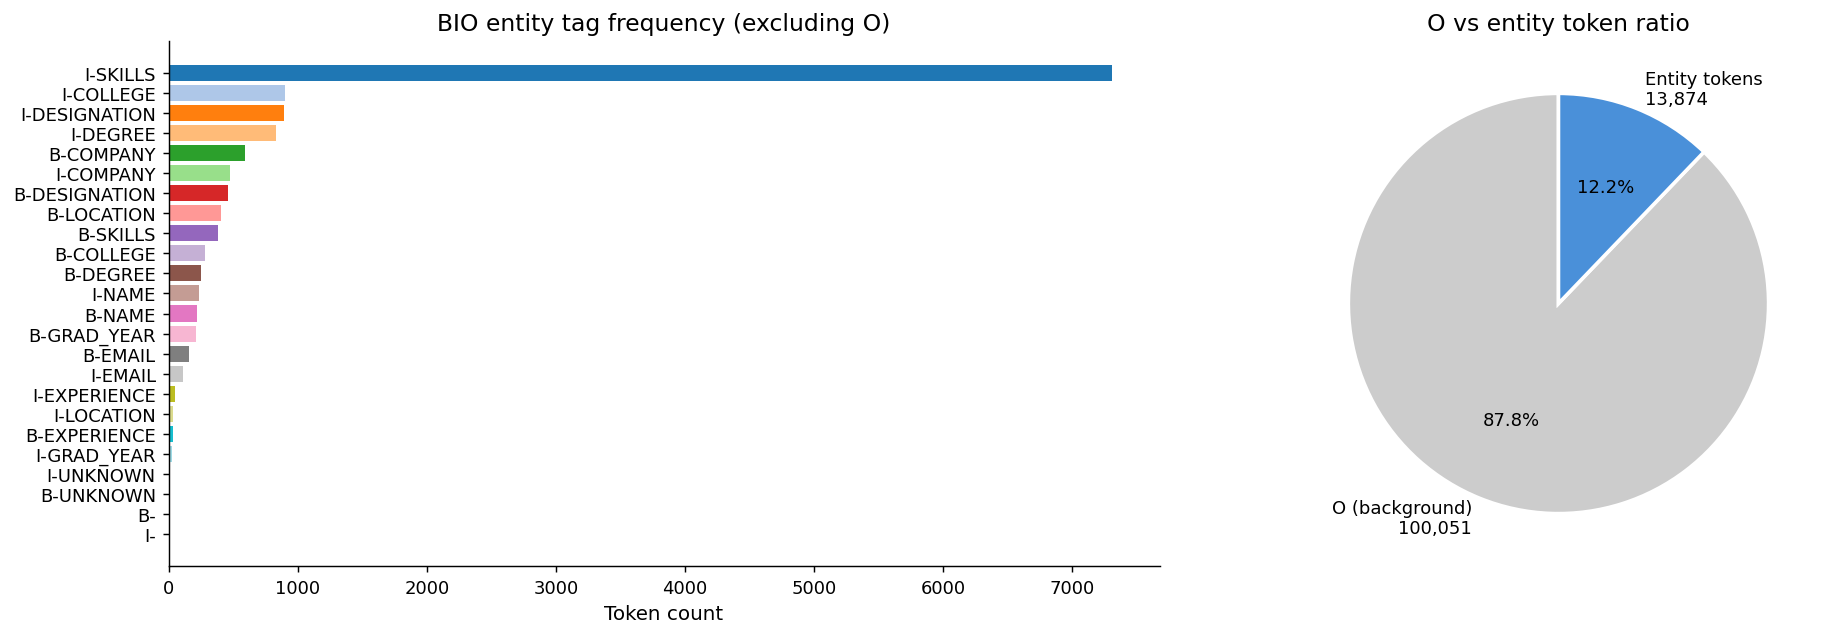

In [ ]:
# ── Label encoding ────────────────────────────────────────────────────────────
# Sort: O first, then alphabetically for reproducibility
ALL_LABELS = ['O'] + sorted(l for l in label_set if l != 'O')
label2id = {l: i for i, l in enumerate(ALL_LABELS)}
id2label  = {i: l for l, i in label2id.items()}
NUM_LABELS = len(ALL_LABELS)

print(f'Number of labels: {NUM_LABELS}')
print('label2id:', label2id)

# ── BIO tag frequency plot ────────────────────────────────────────────────────
all_tags = [tag for sent in ner_sentences for _, tag in sent]
tag_counts = Counter(all_tags)

# Separate O vs entity tags
entity_tags = {k: v for k, v in tag_counts.items() if k != 'O'}
ent_vc = pd.Series(entity_tags).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Entity tag counts
colors = [PALETTE[i % 20] for i in range(len(ent_vc))]
axes[0].barh(ent_vc.index, ent_vc.values, color=colors)
axes[0].set_title('BIO entity tag frequency (excluding O)')
axes[0].set_xlabel('Token count')
axes[0].invert_yaxis()

# O vs Entity ratio
o_count = tag_counts['O']
entity_total = sum(entity_tags.values())
axes[1].pie(
    [o_count, entity_total],
    labels=[f'O (background)\n{o_count:,}', f'Entity tokens\n{entity_total:,}'],
    colors=['#CCCCCC', '#4A90D9'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('O vs entity token ratio')

plt.tight_layout()
plt.savefig('bio_tag_distribution.png', bbox_inches='tight')
plt.show()

## 🔢 Cell 6 — Feature engineering, normalization & PCA

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Build statistical features per resume chunk for PCA / analysis
# (These are NOT used to train the BERT model — that uses raw tokens.
#  But they help us understand the data structure and validate quality.)
# ─────────────────────────────────────────────────────────────────────────────

def extract_chunk_features(sent_pairs):
    """Extract numerical features from a BIO-tagged sentence chunk."""
    tags = [t for _, t in sent_pairs]
    words = [w for w, _ in sent_pairs]

    n = len(tags)
    o_ratio = tags.count('O') / max(n, 1)
    entity_count = sum(1 for t in tags if t.startswith('B-'))

    # Per-label presence (binary)
    entity_types = sorted(label_set - {'O'})
    presence = {lbl: int(any(t == f'B-{lbl}' or t == lbl for t in tags))
                for lbl in entity_types}

    avg_word_len = np.mean([len(w) for w in words]) if words else 0
    has_email    = int(any('@' in w for w in words))
    has_url      = int(any('http' in w.lower() or 'www.' in w.lower() for w in words))
    num_tokens   = n

    feat = {
        'num_tokens'   : num_tokens,
        'o_ratio'      : o_ratio,
        'entity_count' : entity_count,
        'avg_word_len' : avg_word_len,
        'has_email'    : has_email,
        'has_url'      : has_url,
        **presence
    }
    return feat

chunk_feats = [extract_chunk_features(s) for s in ner_sentences]
df_feats = pd.DataFrame(chunk_feats).fillna(0)

print('Feature matrix shape:', df_feats.shape)
print('\nFeature statistics:')
print(df_feats.describe().round(3))

Feature matrix shape: (1248, 30)

Feature statistics:
       num_tokens   o_ratio  entity_count  avg_word_len  has_email   has_url  \
count    1248.000  1248.000      1248.000      1248.000   1248.000  1248.000   
mean       91.286     0.854         2.408         6.242      0.009     0.212   
std        22.204     0.243         3.347         1.992      0.094     0.409   
min         1.000     0.000         0.000         3.000      0.000     0.000   
25%       100.000     0.840         0.000         5.550      0.000     0.000   
50%       100.000     0.970         1.000         5.940      0.000     0.000   
75%       100.000     1.000         4.000         6.440      0.000     0.000   
max       100.000     1.000        23.000        53.000      1.000     1.000   

             B-  B-COLLEGE  B-COMPANY  B-DEGREE  ...  I-COMPANY  I-DEGREE  \
count  1248.000   1248.000   1248.000  1248.000  ...   1248.000  1248.000   
mean      0.001      0.148      0.280     0.142  ...      0.175     0.1

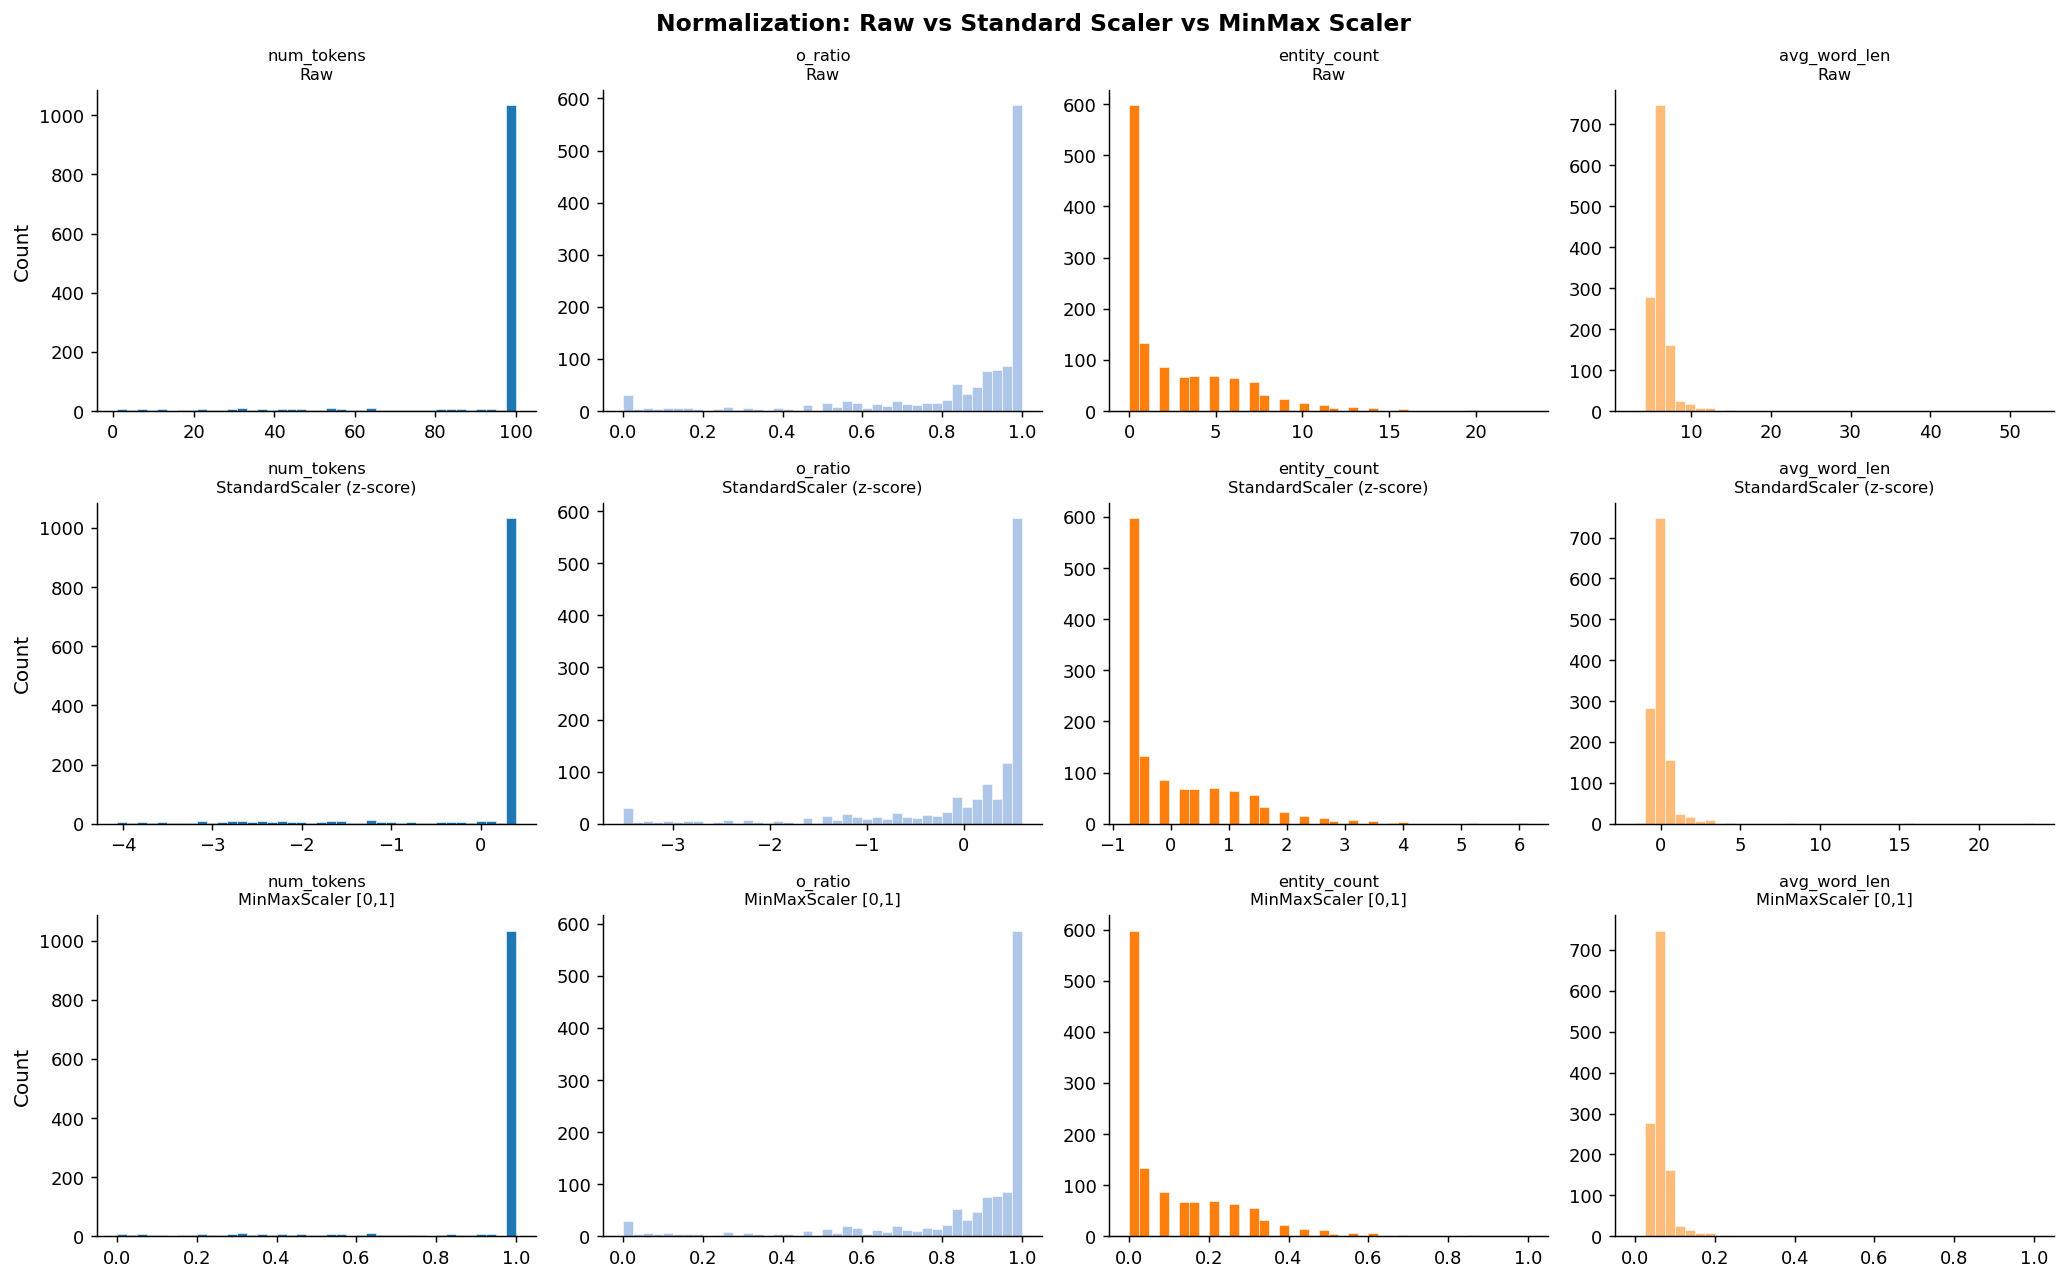

Using StandardScaler output for PCA.


In [ ]:
# ── Normalization comparison (before/after) ───────────────────────────────────
continuous_cols = ['num_tokens', 'o_ratio', 'entity_count', 'avg_word_len']

scaler_std  = StandardScaler()
scaler_mm   = MinMaxScaler()

X_raw    = df_feats[continuous_cols].values
X_std    = scaler_std.fit_transform(X_raw)
X_minmax = scaler_mm.fit_transform(X_raw)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Normalization: Raw vs Standard Scaler vs MinMax Scaler', fontsize=13, fontweight='bold')

for col_idx, col in enumerate(continuous_cols):
    for row_idx, (data, title) in enumerate([
        (X_raw[:, col_idx],    'Raw'),
        (X_std[:, col_idx],    'StandardScaler (z-score)'),
        (X_minmax[:, col_idx], 'MinMaxScaler [0,1]')
    ]):
        ax = axes[row_idx, col_idx]
        ax.hist(data, bins=40, color=PALETTE[col_idx], edgecolor='white', linewidth=0.3)
        ax.set_title(f'{col}\n{title}', fontsize=9)
        ax.set_ylabel('Count' if col_idx == 0 else '')

plt.tight_layout()
plt.savefig('normalization_comparison.png', bbox_inches='tight')
plt.show()

# We'll use StandardScaler for PCA (zero-mean unit-variance is required)
X_scaled = X_std
print('Using StandardScaler output for PCA.')

Components for 95% variance : 20
Components for 99% variance : 25


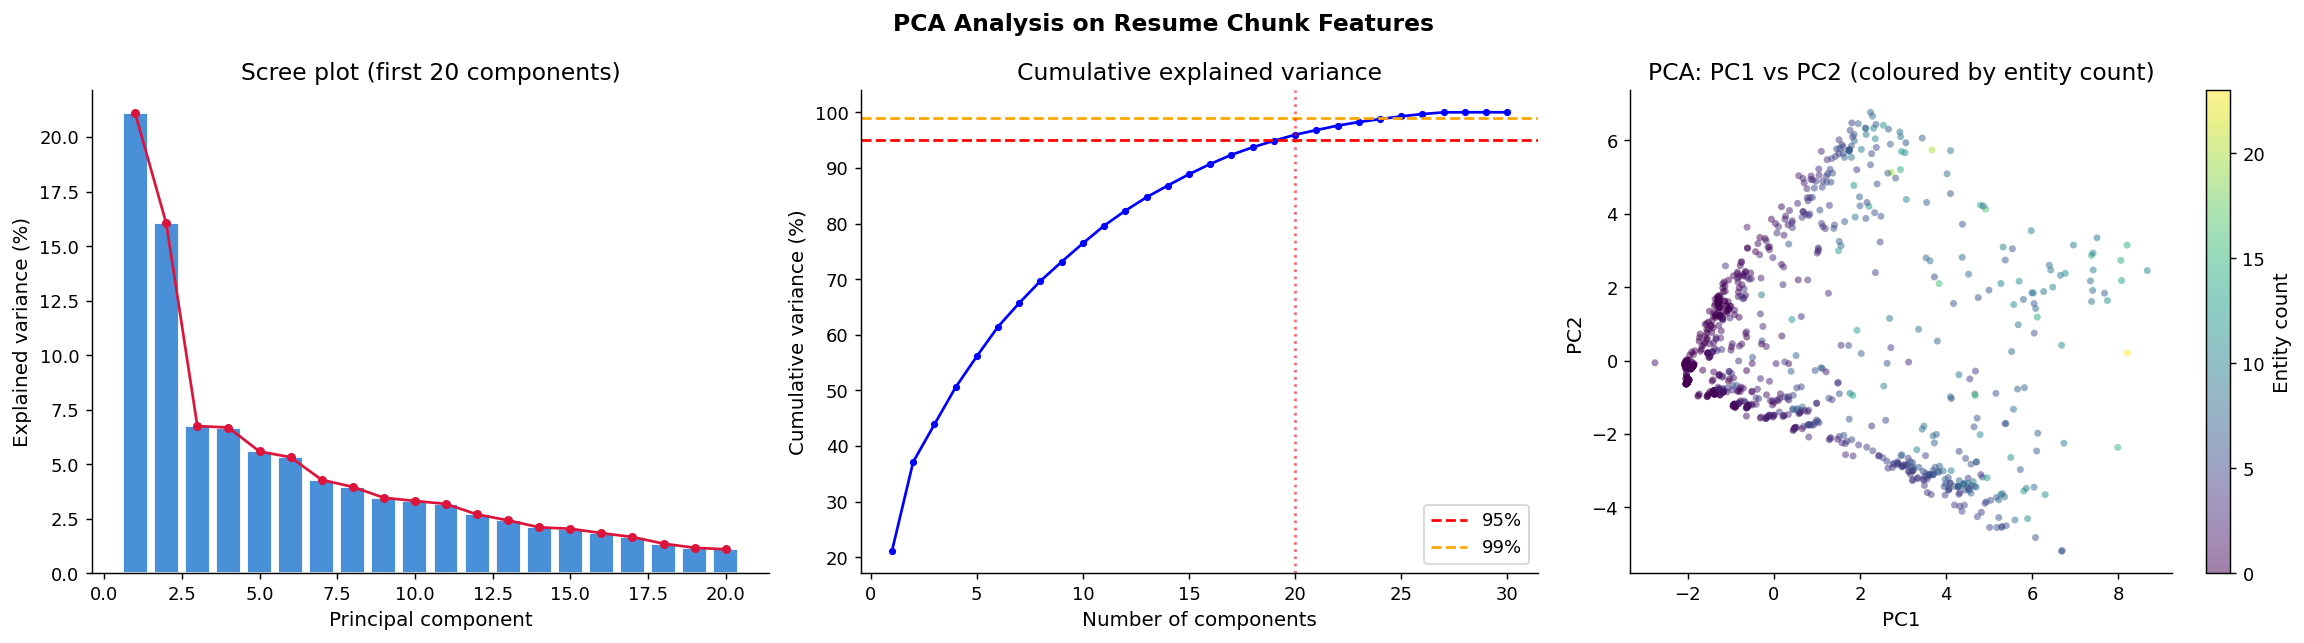

In [ ]:
# ── Full feature matrix (continuous + binary) ─────────────────────────────────
X_all = scaler_std.fit_transform(df_feats.values)

# ── PCA ───────────────────────────────────────────────────────────────────────
pca = PCA(random_state=SEED)
X_pca = pca.fit_transform(X_all)
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

# How many components for 95% variance?
n95 = int(np.searchsorted(cum_explained, 0.95)) + 1
print(f'Components for 95% variance : {n95}')
print(f'Components for 99% variance : {int(np.searchsorted(cum_explained, 0.99)) + 1}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PCA Analysis on Resume Chunk Features', fontsize=13, fontweight='bold')

# Scree plot
ax = axes[0]
ax.bar(range(1, min(21, len(explained)+1)), explained[:20] * 100,
       color='#4A90D9', edgecolor='white')
ax.plot(range(1, min(21, len(explained)+1)), explained[:20] * 100,
        'o-', color='crimson', markersize=4)
ax.set_title('Scree plot (first 20 components)')
ax.set_xlabel('Principal component'); ax.set_ylabel('Explained variance (%)')

# Cumulative explained variance
ax = axes[1]
ax.plot(range(1, len(cum_explained)+1), cum_explained * 100, 'b-o', markersize=3)
ax.axhline(95, color='red', linestyle='--', label='95%')
ax.axhline(99, color='orange', linestyle='--', label='99%')
ax.axvline(n95, color='red', linestyle=':', alpha=0.6)
ax.set_title('Cumulative explained variance')
ax.set_xlabel('Number of components'); ax.set_ylabel('Cumulative variance (%)')
ax.legend()

# PCA scatter (PC1 vs PC2), coloured by entity count
ax = axes[2]
entity_ct = df_feats['entity_count'].values
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=entity_ct,
                cmap='viridis', alpha=0.5, s=15, linewidths=0)
plt.colorbar(sc, ax=ax, label='Entity count')
ax.set_title('PCA: PC1 vs PC2 (coloured by entity count)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.tight_layout()
plt.savefig('pca_analysis.png', bbox_inches='tight')
plt.show()

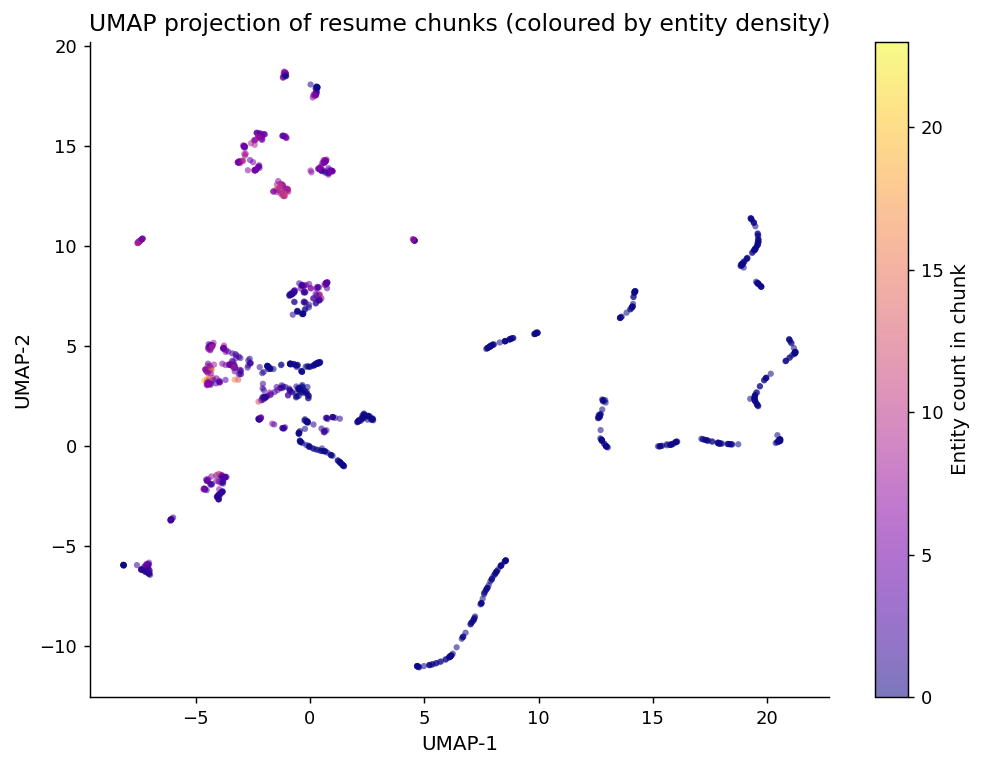

In [ ]:
# ── UMAP projection (richer low-dim view of resume chunks) ────────────────────
try:
    reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
    X_umap = reducer.fit_transform(X_all[:2000])  # subsample for speed
    entity_ct_sub = df_feats['entity_count'].values[:2000]

    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=entity_ct_sub,
                    cmap='plasma', alpha=0.55, s=12, linewidths=0)
    plt.colorbar(sc, ax=ax, label='Entity count in chunk')
    ax.set_title('UMAP projection of resume chunks (coloured by entity density)')
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    plt.tight_layout()
    plt.savefig('umap_projection.png', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'UMAP skipped: {e}')

## ✂️ Cell 7 — Train / Validation / Test split

Train :   872 chunks  (69.9%)
Val   :   187 chunks  (15.0%)
Test  :   188 chunks  (15.1%)

Entity distribution across splits (% of B- tags):
               Train%  Val%  Test%
B-COMPANY        20.0  18.6   20.5
B-DESIGNATION    15.2  16.2   14.9
B-LOCATION       13.4  14.5   13.2
B-SKILLS         13.4   9.6   13.4
B-COLLEGE         9.6   8.3   10.1
B-DEGREE          8.3   8.5    8.3
B-NAME            7.3   7.9    7.3
B-GRAD_YEAR       6.8   8.5    7.1
B-EMAIL           5.2   6.2    4.2
B-EXPERIENCE      0.9   1.7    0.9
B-UNKNOWN         0.1   0.0    0.0


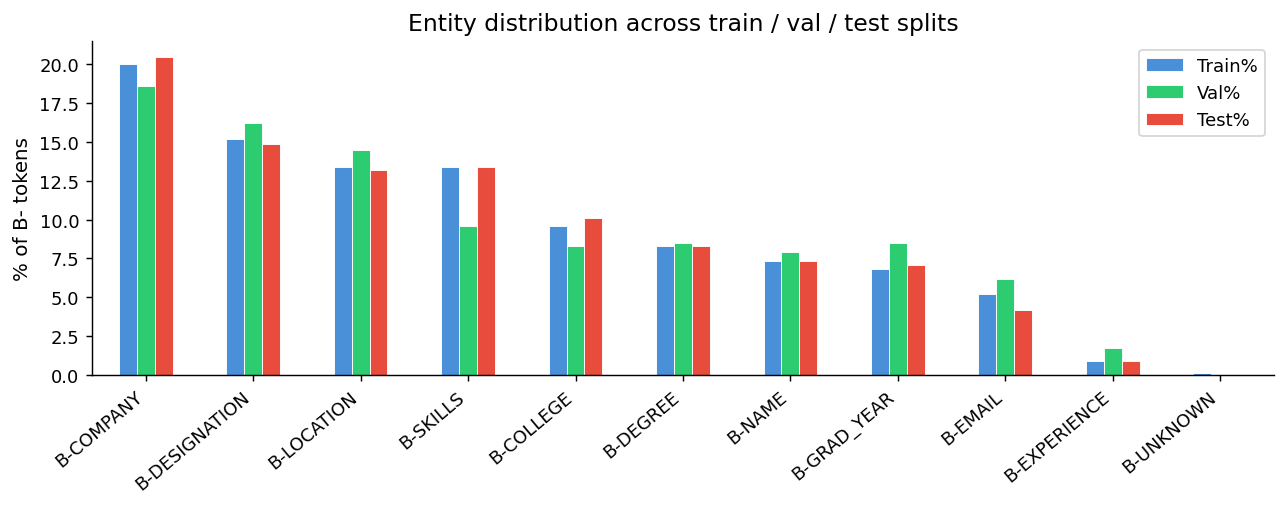

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Stratified split at the sentence (chunk) level
# 70% train / 15% validation / 15% test
# ─────────────────────────────────────────────────────────────────────────────

# Create a coarse stratification key: dominant entity type in each chunk
def dominant_entity(sent):
    ent_tags = [t for _, t in sent if t.startswith('B-')]
    if not ent_tags:
        return 'O_ONLY'
    return Counter(ent_tags).most_common(1)[0][0]

strat_keys = [dominant_entity(s) for s in ner_sentences]

# Filter out classes with < 2 samples (can't stratify)
strat_counts = Counter(strat_keys)
valid_keys   = {k for k, v in strat_counts.items() if v >= 3}
valid_idx    = [i for i, k in enumerate(strat_keys) if k in valid_keys]

# 70/30 → then 30 into 50/50 val/test
train_idx, temp_idx = train_test_split(
    valid_idx, test_size=0.30, random_state=SEED,
    stratify=[strat_keys[i] for i in valid_idx]
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=SEED,
)

train_sents = [ner_sentences[i] for i in train_idx]
val_sents   = [ner_sentences[i] for i in val_idx]
test_sents  = [ner_sentences[i] for i in test_idx]

print(f'Train : {len(train_sents):>5} chunks  ({len(train_sents)/len(valid_idx)*100:.1f}%)')
print(f'Val   : {len(val_sents):>5} chunks  ({len(val_sents)/len(valid_idx)*100:.1f}%)')
print(f'Test  : {len(test_sents):>5} chunks  ({len(test_sents)/len(valid_idx)*100:.1f}%)')

# ── Verify split quality: entity distribution should be similar ───────────────
def entity_dist(sents):
    tags = [t for s in sents for _, t in s if t.startswith('B-')]
    total = len(tags) or 1
    return {t: round(c/total*100, 1) for t, c in Counter(tags).most_common()}

dist_train = entity_dist(train_sents)
dist_val   = entity_dist(val_sents)
dist_test  = entity_dist(test_sents)

split_df = pd.DataFrame({'Train%': dist_train, 'Val%': dist_val, 'Test%': dist_test}).fillna(0)
print('\nEntity distribution across splits (% of B- tags):')
print(split_df)

# Visual confirmation
fig, ax = plt.subplots(figsize=(10, 4))
split_df.plot(kind='bar', ax=ax, color=['#4A90D9', '#2ECC71', '#E74C3C'],
              edgecolor='white', linewidth=0.5)
ax.set_title('Entity distribution across train / val / test splits')
ax.set_ylabel('% of B- tokens'); ax.set_xticklabels(split_df.index, rotation=40, ha='right')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('split_distribution.png', bbox_inches='tight')
plt.show()

## 🤖 Cell 8 — BERT fine-tuning for NER (Token Classification)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Model choice: bert-base-uncased
# For even better accuracy on resume text, alternatives:
#   - 'dslim/bert-base-NER'       (pre-trained NER, fine-tune further)
#   - 'roberta-base'              (stronger, ~5% more RAM)
#   - 'distilbert-base-uncased'   (2x faster, slightly lower accuracy)
# ─────────────────────────────────────────────────────────────────────────────

MODEL_CHECKPOINT = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

print(f'Tokenizer: {MODEL_CHECKPOINT}')
print(f'Vocab size: {tokenizer.vocab_size}')
print(f'Max sequence length: {tokenizer.model_max_length}')

# Quick tokenization test
sample_words = ['Python', 'developer', 'at', 'Google', 'with', '5', 'years', 'experience']
sample_tags  = ['B-SKILLS', 'B-DESIGNATION', 'O', 'B-COMPANY', 'O', 'B-EXPERIENCE', 'I-EXPERIENCE', 'I-EXPERIENCE']
enc = tokenizer(sample_words, is_split_into_words=True, return_offsets_mapping=True)
print(f'\nInput tokens: {len(sample_words)} words → {len(enc["input_ids"])} subword tokens')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: bert-base-uncased
Vocab size: 30522
Max sequence length: 512

Input tokens: 8 words → 10 subword tokens


In [ ]:
# ── PyTorch Dataset class ──────────────────────────────────────────────────────
class NERDataset(Dataset):
    """
    Converts BIO-tagged word-level sentences into BERT-ready token-level inputs.
    Sub-word tokens created by the tokenizer inherit the label of their first word
    (the B- or I- label), while continuation sub-word tokens get label -100
    (ignored in loss computation).
    """
    def __init__(self, sentences, tokenizer, label2id, max_len=256):
        self.sentences  = sentences
        self.tokenizer  = tokenizer
        self.label2id   = label2id
        self.max_len    = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        word_tag_pairs = self.sentences[idx]
        words = [w for w, _ in word_tag_pairs]
        tags  = [t for _, t in word_tag_pairs]

        encoding = self.tokenizer(
            words,
            is_split_into_words=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Align labels with sub-word tokens
        word_ids = encoding.word_ids(batch_index=0)
        label_ids = []
        prev_word_id = None
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)          # [CLS], [SEP], [PAD]
            elif word_id != prev_word_id:
                tag = tags[word_id] if word_id < len(tags) else 'O'
                label_ids.append(self.label2id.get(tag, 0))
            else:
                # Sub-word continuation: use I- version or -100
                tag = tags[word_id] if word_id < len(tags) else 'O'
                if tag.startswith('B-'):
                    label_ids.append(self.label2id.get('I-' + tag[2:], -100))
                else:
                    label_ids.append(-100)      # ignore sub-word continuations
            prev_word_id = word_id

        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'token_type_ids' : encoding.get('token_type_ids', torch.zeros(self.max_len, dtype=torch.long)).squeeze(0),
            'labels'         : torch.tensor(label_ids, dtype=torch.long)
        }


MAX_LEN = 256
train_dataset = NERDataset(train_sents, tokenizer, label2id, MAX_LEN)
val_dataset   = NERDataset(val_sents,   tokenizer, label2id, MAX_LEN)
test_dataset  = NERDataset(test_sents,  tokenizer, label2id, MAX_LEN)

print(f'Train dataset : {len(train_dataset)} samples')
print(f'Val   dataset : {len(val_dataset)} samples')
print(f'Test  dataset : {len(test_dataset)} samples')

# Inspect one sample
sample = train_dataset[0]
print(f'\nInput IDs shape : {sample["input_ids"].shape}')
print(f'Labels shape    : {sample["labels"].shape}')
print(f'Non-(-100) labels: {(sample["labels"] != -100).sum().item()}')

Train dataset : 872 samples
Val   dataset : 187 samples
Test  dataset : 188 samples

Input IDs shape : torch.Size([256])
Labels shape    : torch.Size([256])
Non-(-100) labels: 101


In [ ]:
# ── Load BERT model for token classification ──────────────────────────────────
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)
model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')
print(f'Model on device      : {DEVICE}')

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized be

Total parameters     : 108,910,873
Trainable parameters : 108,910,873
Model on device      : cuda


In [ ]:
# ── Evaluation metric (seqeval — entity-level F1) ─────────────────────────────
from seqeval.metrics import (
    classification_report as seq_report,
    f1_score as seq_f1,
    precision_score as seq_precision,
    recall_score as seq_recall
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    true_seqs, pred_seqs = [], []
    for pred_row, label_row in zip(preds, labels):
        true_seq, pred_seq = [], []
        for p, l in zip(pred_row, label_row):
            if l == -100:
                continue
            true_seq.append(id2label[l])
            pred_seq.append(id2label[p])
        true_seqs.append(true_seq)
        pred_seqs.append(pred_seq)

    return {
        'f1'       : seq_f1(true_seqs, pred_seqs),
        'precision': seq_precision(true_seqs, pred_seqs),
        'recall'   : seq_recall(true_seqs, pred_seqs),
    }

print('Evaluation metric: seqeval entity-level F1 (strict IOB matching)')

Evaluation metric: seqeval entity-level F1 (strict IOB matching)


In [ ]:
# ── Training configuration ─────────────────────────────────────────────────────
OUTPUT_DIR = './resume_parser_model'

training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = 10,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate               = 3e-5,          # sweet spot for BERT fine-tuning
    weight_decay                = 0.01,           # L2 regularisation
    warmup_steps                = 100,            # 100 steps of linear warmup
    lr_scheduler_type           = 'cosine',       # cosine decay after warmup
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    greater_is_better           = True,
    logging_steps               = 50,
    fp16                        = (DEVICE == 'cuda'),  # mixed precision on GPU
    dataloader_num_workers      = 2,
    seed                        = SEED,
    report_to                   = 'none',         # set 'wandb' if you want tracking
)

data_collator = DataCollatorForTokenClassification(
    tokenizer, pad_to_multiple_of=8 if DEVICE == 'cuda' else None
)

trainer = Trainer(
    model              = model,
    args               = training_args,
    train_dataset      = train_dataset,
    eval_dataset       = val_dataset,
    processing_class   = tokenizer,
    data_collator      = data_collator,
    compute_metrics    = compute_metrics,
    callbacks          = [EarlyStoppingCallback(early_stopping_patience=3)]
)

print('Training configuration ready.')
print(f'  Epochs          : {training_args.num_train_epochs}')
print(f'  Batch size      : {training_args.per_device_train_batch_size}')
print(f'  Learning rate   : {training_args.learning_rate}')
print(f'  FP16            : {training_args.fp16}')
print(f'  Early stopping  : patience=3 epochs')

Training configuration ready.
  Epochs          : 10
  Batch size      : 16
  Learning rate   : 3e-05
  FP16            : True
  Early stopping  : patience=3 epochs


In [ ]:
# ── TRAIN ─────────────────────────────────────────────────────────────────────
print('Starting training...')
train_result = trainer.train()

print('\nTraining complete.')
print(f'  Total steps          : {train_result.global_step}')
print(f'  Training loss        : {train_result.training_loss:.4f}')
print(f'  Training time        : {train_result.metrics["train_runtime"]:.1f}s')

# Save best model
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f'\nBest model saved to: {OUTPUT_DIR}')

Starting training...


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,1.992245,0.650609,0.000000,0.000000,0.000000
2,0.509882,0.380671,0.133635,0.167139,0.111321
3,0.341174,0.250940,0.392857,0.391386,0.394340
4,0.218238,0.274343,0.429585,0.463895,0.400000
5,0.173633,0.288665,0.471993,0.459750,0.484906
6,0.139625,0.241009,0.479779,0.467742,0.492453
7,0.116109,0.252393,0.492707,0.431818,0.573585
8,0.097847,0.242614,0.499568,0.460925,0.545283
9,0.089511,0.253370,0.499572,0.456964,0.550943
10,0.077621,0.252938,0.502135,0.458658,0.554717


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training complete.
  Total steps          : 550
  Training loss        : 0.3484
  Training time        : 381.4s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Best model saved to: ./resume_parser_model


## 📈 Cell 9 — Training curves & evaluation

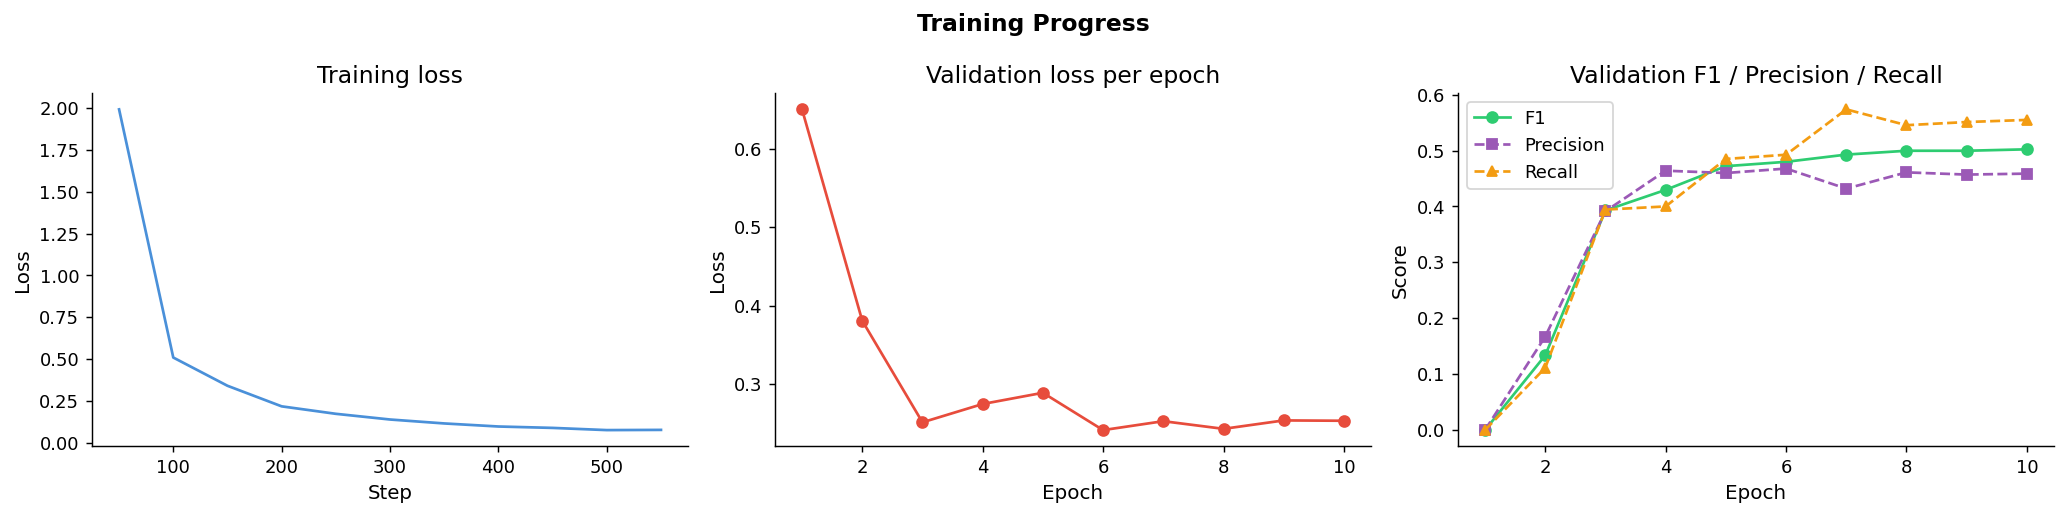

In [ ]:
# ── Plot training curves ───────────────────────────────────────────────────────
log_history = trainer.state.log_history

train_logs = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs  = [x for x in log_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Training Progress', fontsize=13, fontweight='bold')

if train_logs:
    steps  = [x['step'] for x in train_logs]
    losses = [x['loss'] for x in train_logs]
    axes[0].plot(steps, losses, color='#4A90D9', linewidth=1.5)
    axes[0].set_title('Training loss')
    axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')

if eval_logs:
    epochs   = [x['epoch'] for x in eval_logs]
    e_losses = [x['eval_loss'] for x in eval_logs]
    e_f1s    = [x.get('eval_f1', 0) for x in eval_logs]
    e_prec   = [x.get('eval_precision', 0) for x in eval_logs]
    e_rec    = [x.get('eval_recall', 0) for x in eval_logs]

    axes[1].plot(epochs, e_losses, 'o-', color='#E74C3C', label='Val loss')
    axes[1].set_title('Validation loss per epoch')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')

    axes[2].plot(epochs, e_f1s,  'o-', color='#2ECC71', label='F1')
    axes[2].plot(epochs, e_prec, 's--', color='#9B59B6', label='Precision')
    axes[2].plot(epochs, e_rec,  '^--', color='#F39C12', label='Recall')
    axes[2].set_title('Validation F1 / Precision / Recall')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Score')
    axes[2].legend()

plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Final evaluation on TEST set ──────────────────────────────────────────────
print('Evaluating on held-out TEST set...')
test_results = trainer.evaluate(eval_dataset=test_dataset)

print(f"\n{'='*50}")
print('TEST SET RESULTS')
print(f"{'='*50}")
print(f"  Loss      : {test_results['eval_loss']:.4f}")
print(f"  F1        : {test_results['eval_f1']:.4f}")
print(f"  Precision : {test_results['eval_precision']:.4f}")
print(f"  Recall    : {test_results['eval_recall']:.4f}")

# ── Per-entity detailed report ────────────────────────────────────────────────
print('\nGenerating per-entity classification report...')

all_true, all_pred = [], []
model.eval()
loader = DataLoader(test_dataset, batch_size=32)

with torch.no_grad():
    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        logits  = outputs.logits
        preds   = torch.argmax(logits, dim=-1).cpu().numpy()
        labels  = batch['labels'].cpu().numpy()

        for pred_row, label_row in zip(preds, labels):
            t_seq, p_seq = [], []
            for p, l in zip(pred_row, label_row):
                if l == -100: continue
                t_seq.append(id2label[l])
                p_seq.append(id2label[p])
            all_true.append(t_seq)
            all_pred.append(p_seq)

print('\nPer-entity F1 report:')
print(seq_report(all_true, all_pred, digits=4))

Evaluating on held-out TEST set...



TEST SET RESULTS
  Loss      : 0.1994
  F1        : 0.5278
  Precision : 0.5046
  Recall    : 0.5533

Generating per-entity classification report...

Per-entity F1 report:
              precision    recall  f1-score   support

     COLLEGE     0.3492    0.4314    0.3860        51
     COMPANY     0.5321    0.5631    0.5472       103
      DEGREE     0.4561    0.6047    0.5200        43
 DESIGNATION     0.4932    0.5217    0.5070        69
       EMAIL     0.7576    1.0000    0.8621        25
  EXPERIENCE     0.1111    0.2000    0.1429         5
   GRAD_YEAR     0.6000    0.5000    0.5455        36
    LOCATION     0.6129    0.6552    0.6333        58
        NAME     0.9394    1.0000    0.9688        31
      SKILLS     0.2632    0.2632    0.2632        76

   micro avg     0.5046    0.5533    0.5278       497
   macro avg     0.5115    0.5739    0.5376       497
weighted avg     0.5071    0.5533    0.5273       497



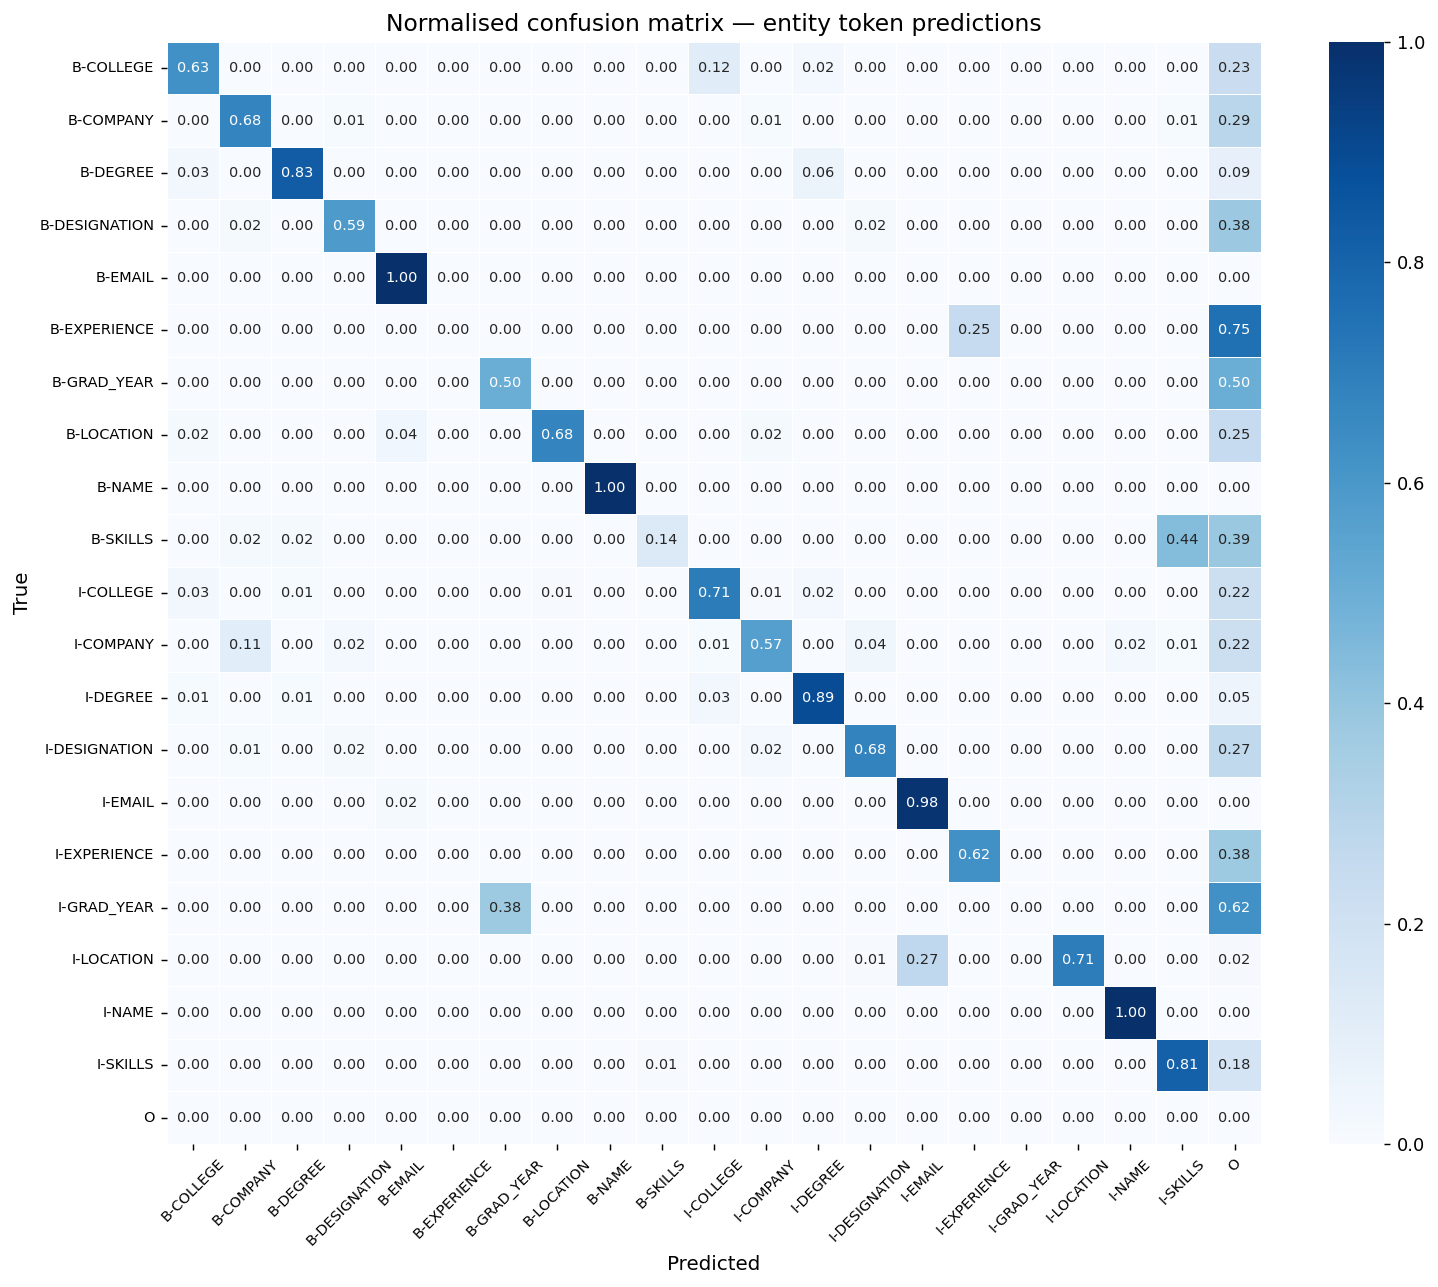

In [ ]:
# ── Confusion matrix (entity-level, flattened) ────────────────────────────────
flat_true = [t for seq in all_true for t in seq if t != 'O']
flat_pred = [p for ts, ps in zip(all_true, all_pred)
             for t, p in zip(ts, ps) if t != 'O']

entity_labels = sorted(set(flat_true + flat_pred))
cm = confusion_matrix(flat_true, flat_pred, labels=entity_labels, normalize='true')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, xticklabels=entity_labels, yticklabels=entity_labels,
            annot=True, fmt='.2f', cmap='Blues', linewidths=0.4, ax=ax,
            annot_kws={'size': 8})
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title('Normalised confusion matrix — entity token predictions', fontsize=13)
ax.tick_params(axis='x', labelsize=8, rotation=45)
ax.tick_params(axis='y', labelsize=8, rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

## 🔍 Cell 10 — Inference pipeline: resume → structured JSON

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Full inference pipeline:
#   1. Accept plain text (from PDF extraction via pdfplumber)
#   2. Tokenize and run BERT NER
#   3. Reconstruct word-level entities from sub-word predictions
#   4. Group consecutive tokens into entity spans
#   5. Output structured JSON for downstream models
# ─────────────────────────────────────────────────────────────────────────────

from transformers import pipeline as hf_pipeline

# Load the fine-tuned model as a HuggingFace NER pipeline
ner_pipeline = hf_pipeline(
    'ner',
    model=OUTPUT_DIR,
    tokenizer=OUTPUT_DIR,
    aggregation_strategy='simple',   # merge consecutive same-label tokens
    device=0 if DEVICE == 'cuda' else -1
)


def chunk_text(text, chunk_size=400):
    """Split long text into overlapping chunks to handle BERT's 512 token limit."""
    words = text.split()
    overlap = 50
    chunks = []
    for start in range(0, len(words), chunk_size - overlap):
        chunk = ' '.join(words[start:start + chunk_size])
        chunks.append(chunk)
        if start + chunk_size >= len(words):
            break
    return chunks


def parse_resume(text: str) -> dict:
    """
    Main inference function.
    Input : raw resume text (string)
    Output: structured dict ready for Model 2 (Scorer) and Model 3 (Recommender)
    """
    chunks = chunk_text(text)

    # Aggregate entities from all chunks
    entities_raw = defaultdict(list)
    for chunk in chunks:
        results = ner_pipeline(chunk)
        for ent in results:
            lbl = ent['entity_group'].upper().replace(' ', '_')
            val = ent['word'].strip()
            if val and ent['score'] > 0.70:
                entities_raw[lbl].append(val)

    # Deduplicate and normalise
    def dedup(lst):
        seen, out = set(), []
        for x in lst:
            xn = x.lower()
            if xn not in seen:
                seen.add(xn); out.append(x)
        return out

    # Build structured output
    parsed = {
        'name'            : entities_raw.get('NAME', [''])[0],
        'email'           : entities_raw.get('EMAIL', [''])[0],
        'phone'           : entities_raw.get('PHONE', [''])[0],
        'location'        : dedup(entities_raw.get('LOCATION', [])),
        'links'           : dedup(entities_raw.get('LINKS', [])),
        'skills'          : dedup(entities_raw.get('SKILLS', [])),
        'designations'    : dedup(entities_raw.get('DESIGNATION', [])),
        'companies'       : dedup(entities_raw.get('COMPANY', [])),
        'degree'          : dedup(entities_raw.get('DEGREE', [])),
        'colleges'        : dedup(entities_raw.get('COLLEGE', [])),
        'graduation_year' : dedup(entities_raw.get('GRAD_YEAR', [])),
        'years_experience': entities_raw.get('EXPERIENCE', [''])[0],
        'certifications'  : dedup(entities_raw.get('CERTIFICATION', [])),
        '_meta': {
            'model'  : 'resume-parser-bert-v1',
            'chunks' : len(chunks),
        }
    }

    return parsed


# ── Demo inference on a sample resume ─────────────────────────────────────────
SAMPLE_RESUME = """
Rahul Sharma
rahul.sharma@gmail.com | +91-9876543210 | Bangalore, India
LinkedIn: linkedin.com/in/rahul-sharma

SKILLS
Python, Machine Learning, Deep Learning, TensorFlow, PyTorch, Scikit-learn,
SQL, REST APIs, Docker, Git, AWS, NLP, Computer Vision

EXPERIENCE
Data Scientist — TCS (Tata Consultancy Services)
June 2021 – Present | Bangalore
- Built end-to-end ML pipelines reducing churn by 18%
- Deployed 3 NLP models in production using FastAPI and Docker
3 years of experience

EDUCATION
B.Tech in Computer Science — IIT Bombay | 2021
CGPA: 8.9/10

CERTIFICATIONS
AWS Certified Machine Learning Specialty
Google Professional Data Engineer
"""

result = parse_resume(SAMPLE_RESUME)
print('\n' + '='*55)
print('PARSED RESUME OUTPUT (JSON)')
print('='*55)
print(json.dumps(result, indent=2, ensure_ascii=False))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


PARSED RESUME OUTPUT (JSON)
{
  "name": "rahul sharma",
  "email": "| + 91 - 9876543210",
  "phone": "",
  "location": [
    "bangalore,",
    ")"
  ],
  "links": [],
  "skills": [
    "python, machine learning, deep learning, tensorflow, pytorch, scikit - learn, sql, rest apis, docker, git, aws, nlp, computer vision"
  ],
  "designations": [
    "data scientist"
  ],
  "companies": [
    "services"
  ],
  "degree": [
    "b. tech in computer science"
  ],
  "colleges": [
    "iit bombay"
  ],
  "graduation_year": [],
  "years_experience": "",
  "certifications": [],
  "_meta": {
    "model": "resume-parser-bert-v1",
    "chunks": 1
  }
}


## 💾 Cell 11 — Save model & export for production

In [ ]:
# ── Save label mappings alongside model ───────────────────────────────────────
label_config = {'label2id': label2id, 'id2label': id2label, 'all_labels': ALL_LABELS}
with open(os.path.join(OUTPUT_DIR, 'label_config.json'), 'w') as f:
    json.dump(label_config, f, indent=2)

# ── Export a minimal inference-only wrapper ────────────────────────────────────
WRAPPER_CODE = '''
"""
resume_parser.py  — Production inference wrapper for Model 1
Usage:
    from resume_parser import ResumeParser
    parser = ResumeParser('path/to/saved_model')
    result = parser.parse_pdf('resume.pdf')
"""
import json, re
from collections import defaultdict
import pdfplumber
from transformers import pipeline as hf_pipeline


class ResumeParser:
    def __init__(self, model_dir: str, device: int = -1):
        self.ner = hf_pipeline(
            'ner', model=model_dir, tokenizer=model_dir,
            aggregation_strategy='simple', device=device
        )

    def extract_text(self, pdf_path: str) -> str:
        """Extract text from PDF using pdfplumber."""
        text = ""
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                text += (page.extract_text() or "") + "\\n"
        return text.strip()

    def parse_text(self, text: str) -> dict:
        words = text.split()
        chunks, size, overlap = [], 400, 50
        for start in range(0, len(words), size - overlap):
            chunks.append(" ".join(words[start:start + size]))
            if start + size >= len(words): break

        entities_raw = defaultdict(list)
        for chunk in chunks:
            for ent in self.ner(chunk):
                lbl = ent["entity_group"].upper().replace(" ", "_")
                if ent["score"] > 0.70:
                    entities_raw[lbl].append(ent["word"].strip())

        def dedup(lst):
            seen, out = set(), []
            for x in lst:
                if x.lower() not in seen: seen.add(x.lower()); out.append(x)
            return out

        return {
            "name": entities_raw.get("NAME", [""])[0],
            "email": entities_raw.get("EMAIL", [""])[0],
            "phone": entities_raw.get("PHONE", [""])[0],
            "location": dedup(entities_raw.get("LOCATION", [])),
            "skills": dedup(entities_raw.get("SKILLS", [])),
            "designations": dedup(entities_raw.get("DESIGNATION", [])),
            "companies": dedup(entities_raw.get("COMPANY", [])),
            "degree": dedup(entities_raw.get("DEGREE", [])),
            "colleges": dedup(entities_raw.get("COLLEGE", [])),
            "graduation_year": dedup(entities_raw.get("GRAD_YEAR", [])),
            "years_experience": entities_raw.get("EXPERIENCE", [""])[0],
            "certifications": dedup(entities_raw.get("CERTIFICATION", [])),
        }

    def parse_pdf(self, pdf_path: str) -> dict:
        text = self.extract_text(pdf_path)
        return self.parse_text(text)
'''

with open('resume_parser.py', 'w') as f:
    f.write(WRAPPER_CODE)

print('Saved files:')
print('  ✅ ./resume_parser_model/          — fine-tuned BERT weights')
print('  ✅ ./resume_parser_model/label_config.json')
print('  ✅ ./resume_parser.py              — production inference wrapper')
print('  ✅ eda_overview.png')
print('  ✅ training_curves.png')
print('  ✅ confusion_matrix.png')

print(f'\n📊 Final test F1   : {test_results["eval_f1"]:.4f}')
print(f'📊 Final precision  : {test_results["eval_precision"]:.4f}')
print(f'📊 Final recall     : {test_results["eval_recall"]:.4f}')

Saved files:
  ✅ ./resume_parser_model/          — fine-tuned BERT weights
  ✅ ./resume_parser_model/label_config.json
  ✅ ./resume_parser.py              — production inference wrapper
  ✅ eda_overview.png
  ✅ training_curves.png
  ✅ confusion_matrix.png

📊 Final test F1   : 0.5278
📊 Final precision  : 0.5046
📊 Final recall     : 0.5533


# Downloading the Model on Local System

In [34]:
import os
import shutil
import subprocess

# 1. Create a brand new, empty staging directory
staging_dir = "clean_production_model"
if os.path.exists(staging_dir):
    shutil.rmtree(staging_dir)
os.makedirs(staging_dir)

# 2. Extract ONLY the exact files needed for inference (Ignoring all checkpoints/optimizers)
source_dir = "resume_parser_model"
required_model_files = [
    "model.safetensors",        # The actual neural network weights (~415 MB)
    "config.json",              # BERT architecture config
    "tokenizer.json",           # Vocabulary mappings
    "tokenizer_config.json",    # Tokenizer settings
    "special_tokens_map.json",  # [CLS], [SEP], etc.
    "vocab.txt",                # Fallback vocab
    "label_config.json"         # Your custom NER labels
]

print("Copying core model files...")
for file in required_model_files:
    src = os.path.join(source_dir, file)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(staging_dir, file))

# 3. Copy your wrapper script and graphs
extra_files = ["resume_parser.py", "eda_overview.png", "training_curves.png", "confusion_matrix.png"]
for file in extra_files:
    if os.path.exists(file):
        shutil.copy2(file, staging_dir)

# 4. Zip ONLY this clean, isolated directory
zip_name = "FINAL_resume_parser_model1"
shutil.make_archive(zip_name, 'zip', staging_dir)

# 5. Verify the size is correct (~400 MB)
zip_filename = f"{zip_name}.zip"
size_mb = os.path.getsize(zip_filename) / (1024 * 1024)
print(f"✅ Clean Zip created! Exact size: {size_mb:.2f} MB")

# 6. Copy safely to Google Drive
from google.colab import drive
drive.mount('/content/drive')
shutil.copy(zip_filename, f'/content/drive/MyDrive/{zip_filename}')

print(f"✅ {zip_filename} successfully copied to the root of your Google Drive!")

Copying core model files...
✅ Clean Zip created! Exact size: 385.38 MB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ FINAL_resume_parser_model1.zip successfully copied to the root of your Google Drive!
